<a href="https://colab.research.google.com/github/Hardik-Anand4442/cybersecurity-threat-detection/blob/main/NTCCProject(main).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

#NBSW-NB15 DATASET


In [ ]:
train_url = "https://raw.githubusercontent.com/ushukkla/nospammers/master/UNSW_NB15_training-set.csv"
test_url = "https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Dataset loaded successfully")
print(train_df.shape)
print(test_df.shape)

Dataset loaded successfully
(82332, 45)
(82332, 45)


In [ ]:
print(train_df.shape)
print(test_df.shape)

train_df.head(1000)

(82332, 45)
(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1.183870,tcp,-,FIN,14,14,784,764,22.806559,...,1,3,0,0,0,2,4,0,Fuzzers,1
996,997,0.195360,tcp,http,FIN,10,6,1330,268,76.781325,...,1,1,0,0,1,1,1,0,Exploits,1
997,998,0.230088,tcp,http,FIN,10,10,816,5840,82.577103,...,1,1,0,0,1,1,1,0,Exploits,1
998,999,0.212793,tcp,http,FIN,12,20,876,19342,145.681489,...,1,1,0,0,1,2,1,0,DoS,1


In [ ]:
print(train_df.columns.tolist())

print(train_df['attack_cat'].value_counts())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [ ]:
train_df = train_df.dropna()
test_df = test_df.dropna()

train_df['attack_cat'] = train_df['attack_cat'].str.strip()
test_df['attack_cat'] = test_df['attack_cat'].str.strip()

print(train_df['attack_cat'].value_counts())

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [ ]:
drop_cols = ['id', 'label']

train_df = train_df.drop(columns=drop_cols, errors='ignore')
test_df = test_df.drop(columns=drop_cols, errors='ignore')

In [ ]:
categorical_cols = ['proto', 'service', 'state']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    combined_values = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined_values)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

    encoders[col] = le

In [ ]:
target_encoder = LabelEncoder()

target_encoder.fit(pd.concat([train_df['attack_cat'], test_df['attack_cat']], axis=0))

train_df['attack_cat'] = target_encoder.transform(train_df['attack_cat'])
test_df['attack_cat'] = target_encoder.transform(test_df['attack_cat'])

print(list(target_encoder.classes_))

['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [ ]:
X_train = train_df.drop('attack_cat', axis=1)
y_train = train_df['attack_cat']

X_test = test_df.drop('attack_cat', axis=1)
y_test = test_df['attack_cat']

feature_columns = X_train.columns.tolist()

print(X_train.shape)
print(X_test.shape)

(82332, 42)
(82332, 42)


Insttallation of Lightgbm,Catboost


In [ ]:
!pip install lightgbm catboost -q

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1:", rf_f1)

Random Forest Accuracy: 0.9360151581402127
Random Forest F1: 0.933321935275822


XGBoost Classifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average='weighted')
xgb_recall = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost F1:", xgb_f1)

XGBoost Accuracy: 0.9291041150463976
XGBoost F1: 0.9262845332136745


LightGBM Classifier

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, average='weighted')
lgbm_recall = recall_score(y_test, lgbm_pred, average='weighted')
lgbm_f1 = f1_score(y_test, lgbm_pred, average='weighted')

print("LightGBM Accuracy:", lgbm_accuracy)
print("LightGBM F1:", lgbm_f1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5997
[LightGBM] [Info] Number of data points in the train set: 82332, number of used features: 42
[LightGBM] [Info] Start training from score -4.800844
[LightGBM] [Info] Start training from score -4.950328
[LightGBM] [Info] Start training from score -3.002459
[LightGBM] [Info] Start training from score -2.000936
[LightGBM] [Info] Start training from score -2.608720
[LightGBM] [Info] Start training from score -1.473134
[LightGBM] [Info] Start training from score -0.799842
[LightGBM] [Info] Start training from score -3.159140
[LightGBM] [Info] Start training from score -5.383621
[LightGBM] [Info] Start training from score -7.534325
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

CatBoost Classifier

In [ ]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.08,
    depth=8,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

cat_accuracy = accuracy_score(y_test, cat_pred)
cat_precision = precision_score(y_test, cat_pred, average='weighted')
cat_recall = recall_score(y_test, cat_pred, average='weighted')
cat_f1 = f1_score(y_test, cat_pred, average='weighted')

print("CatBoost Accuracy:", cat_accuracy)
print("CatBoost F1:", cat_f1)

CatBoost Accuracy: 0.8882208618763057
CatBoost F1: 0.8836576691765224


In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],

    "Precision": [
        rf_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision
    ],

    "Recall": [
        rf_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.936015,0.945008,0.936015,0.933322
1,XGBoost,0.929104,0.937738,0.929104,0.926285
2,LightGBM,0.828973,0.829366,0.828973,0.828322
3,CatBoost,0.888221,0.892086,0.888221,0.883658


In [ ]:
joblib.dump(rf_model, "final_rf_model.pkl")

print("Final Random Forest model saved")

Final Random Forest model saved


In [ ]:
from google.colab import files
files.download("final_rf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

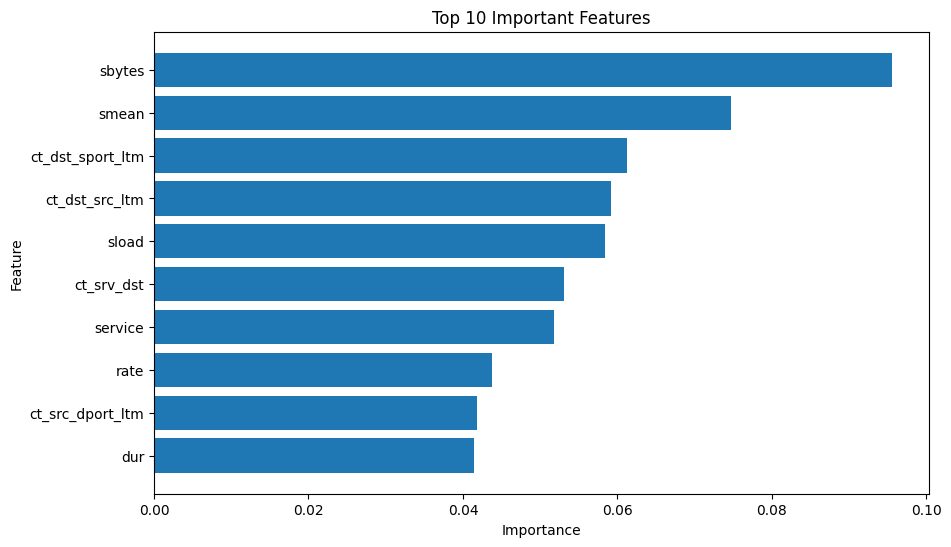

In [ ]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
joblib.dump(rf_model, "final_rf_model.pkl")

joblib.dump(encoders, "final_feature_encoders.pkl")

joblib.dump(target_encoder, "final_target_encoder.pkl")

joblib.dump(feature_columns, "final_feature_columns.pkl")

print("Final deployed files saved")

Final deployed files saved


In [ ]:
from google.colab import files

files.download("final_rf_model.pkl")
files.download("final_feature_encoders.pkl")
files.download("final_target_encoder.pkl")
files.download("final_feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Dataset Upgrade

the earlier datasets were reviewed for limitations such as outdated traffic patterns, synthetic data generation, class imbalance, and noisy labels. To improve the reliability and research quality of the project, additional intrusion detection datasets are being explored and compared.

The CICIDS2017 dataset was selected for further experimentation because it contains benign traffic and common real-world attack scenarios. It also provides labeled network flow features extracted using CICFlowMeter, making it suitable for machine-learning-based intrusion detection.

In [ ]:
!pip install kagglehub -q

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

In [ ]:
import kagglehub

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Dataset downloaded at:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset downloaded at: /kaggle/input/network-intrusion-dataset
['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [ ]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:", len(csv_files))
csv_files

CSV files found: 8


['/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 '/kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv']

In [ ]:
df_list = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

cic_df = pd.concat(df_list, ignore_index=True)

print(cic_df.shape)
cic_df.head()

(2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
cic_df.columns = cic_df.columns.str.strip()

print(cic_df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
print(cic_df['Label'].value_counts())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
cic_df = cic_df.replace([np.inf, -np.inf], np.nan)
cic_df = cic_df.dropna()

print(cic_df.shape)
print(cic_df['Label'].value_counts())

(2827876, 79)
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
cic_sample = cic_df.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 10000), random_state=42)
)

print(cic_sample.shape)
print(cic_sample['Label'].value_counts())

(79310, 79)
Label
BENIGN                        10000
DDoS                          10000
DoS GoldenEye                 10000
DoS Hulk                      10000
PortScan                      10000
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64


/tmp/ipykernel_5735/1269878755.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cic_sample = cic_df.groupby('Label', group_keys=False).apply(


In [ ]:
label_encoder_cic = LabelEncoder()

cic_sample['Label'] = label_encoder_cic.fit_transform(cic_sample['Label'])

print(list(label_encoder_cic.classes_))

['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [ ]:
X = cic_sample.drop('Label', axis=1)
y = cic_sample['Label']

X = X.select_dtypes(include=[np.number])

print(X.shape)
print(y.shape)

(79310, 78)
(79310,)


In [ ]:
X_train_cic, X_test_cic, y_train_cic, y_test_cic = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf_cic = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_cic.fit(X_train_cic, y_train_cic)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
rf_cic_pred = rf_cic.predict(X_test_cic)

rf_cic_accuracy = accuracy_score(y_test_cic, rf_cic_pred)
rf_cic_precision = precision_score(y_test_cic, rf_cic_pred, average='weighted')
rf_cic_recall = recall_score(y_test_cic, rf_cic_pred, average='weighted')
rf_cic_f1 = f1_score(y_test_cic, rf_cic_pred, average='weighted')

print("CICIDS2017 Random Forest Accuracy:", rf_cic_accuracy)
print("CICIDS2017 Random Forest Precision:", rf_cic_precision)
print("CICIDS2017 Random Forest Recall:", rf_cic_recall)
print("CICIDS2017 Random Forest F1 Score:", rf_cic_f1)

print(classification_report(
    y_test_cic,
    rf_cic_pred,
    target_names=label_encoder_cic.classes_
))

CICIDS2017 Random Forest Accuracy: 0.9873912495271718
CICIDS2017 Random Forest Precision: 0.986573612153056
CICIDS2017 Random Forest Recall: 0.9873912495271718
CICIDS2017 Random Forest F1 Score: 0.9869125371048421
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99      2000
                       Bot       0.99      0.99      0.99       391
                      DDoS       1.00      1.00      1.00      2000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      1.00      1.00      2000
          DoS Slowhttptest       0.99      0.99      0.99      1100
             DoS slowloris       0.99      1.00      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       1.00

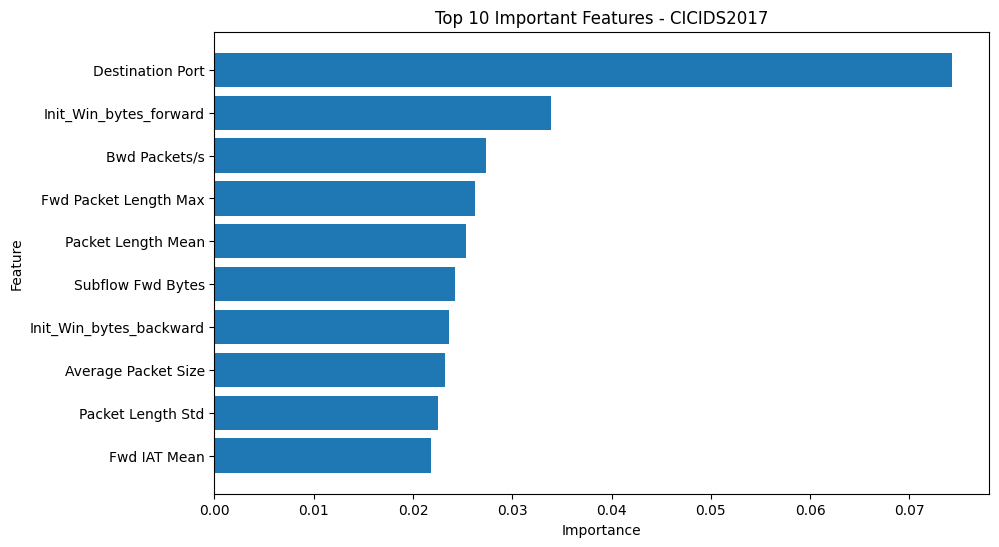

In [ ]:
import matplotlib.pyplot as plt

feature_importance_cic = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_cic.feature_importances_
})

feature_importance_cic = feature_importance_cic.sort_values(
    by="Importance",
    ascending=False
)

top_cic_features = feature_importance_cic.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cic_features["Feature"], top_cic_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - CICIDS2017")
plt.gca().invert_yaxis()
plt.show()

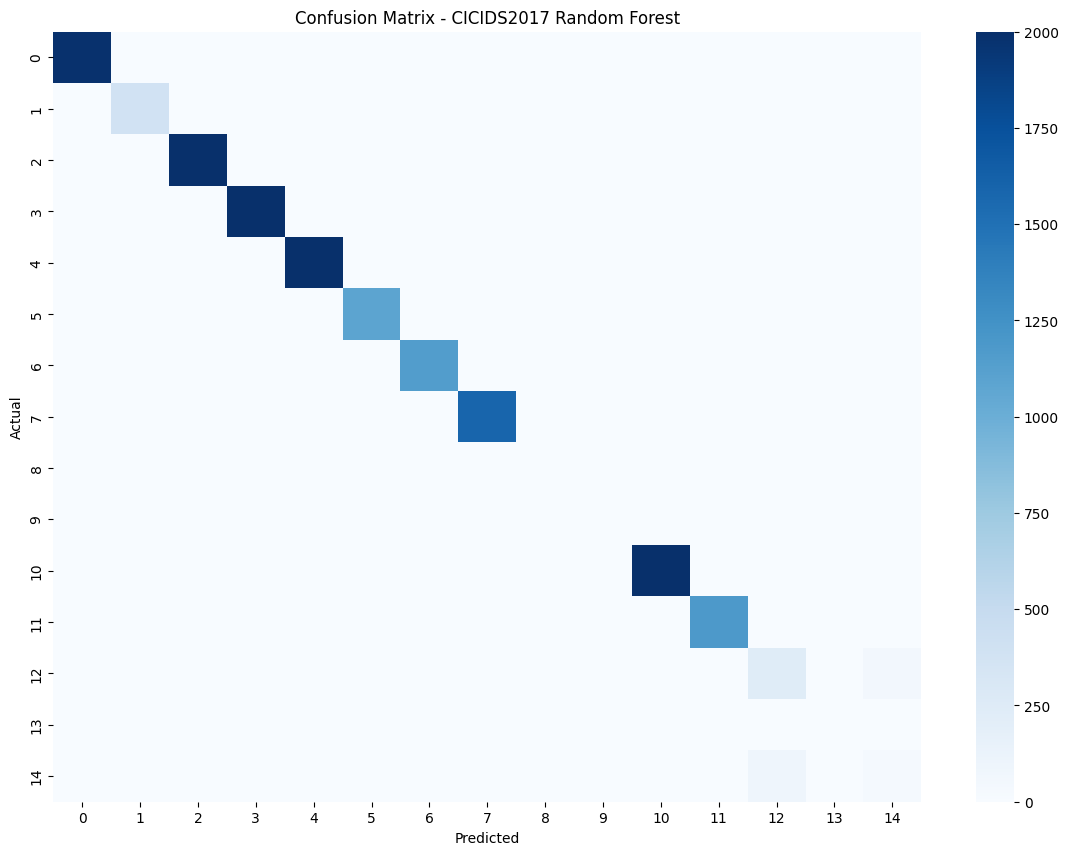

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cic, rf_cic_pred)

plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix - CICIDS2017 Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# TON_IoT Dataset Review

The TON_IoT dataset was explored as part of the research study to analyze modern IoT-based cyberattacks. The dataset includes telemetry data from IoT devices, Windows/Linux operating systems, network traffic, and attack scenarios such as ransomware, backdoor attacks, DDoS, and password attacks.

However, due to the large dataset size and complex preprocessing requirements, the dataset was reviewed for comparative analysis and future scope rather than full deployment in the current implementation.

In [ ]:
!pip install kagglehub xgboost lightgbm catboost -q

import os
import pandas as pd
import numpy as np
import joblib
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
def train_compare_models(df, label_col, dataset_name, max_per_class=8000):
    print(f"\n===== {dataset_name} EXPERIMENT =====")

    df = df.copy()
    df.columns = df.columns.str.strip()

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    print("Original shape:", df.shape)
    print("Original labels:")
    print(df[label_col].value_counts())

    df = df.groupby(label_col, group_keys=False).apply(
        lambda x: x.sample(min(len(x), max_per_class), random_state=42)
    )

    print("\nSampled shape:", df.shape)
    print("Sampled labels:")
    print(df[label_col].value_counts())

    y_raw = df[label_col].astype(str)
    X = df.drop(columns=[label_col], errors="ignore")

    for col in X.columns:
        if X[col].dtype == "object":
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    X = X.select_dtypes(include=[np.number])

    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y_raw)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=8,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=200,
            learning_rate=0.08,
            max_depth=8,
            random_state=42,
            verbose=-1
        ),

        "CatBoost": CatBoostClassifier(
            iterations=200,
            learning_rate=0.08,
            depth=8,
            verbose=0,
            random_state=42
        )
    }

    results = []

    best_model = None
    best_model_name = None
    best_f1 = -1

    for name, model in models.items():
        print(f"\nTraining {name} on {dataset_name}...")

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1
        })

        print(name, "Accuracy:", acc)
        print(name, "F1:", f1)

        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_model_name = name

    result_df = pd.DataFrame(results)

    return {
        "dataset": dataset_name,
        "results": result_df,
        "best_model": best_model,
        "best_model_name": best_model_name,
        "best_f1": best_f1,
        "feature_columns": list(X.columns),
        "target_encoder": target_encoder,
        "classes": list(target_encoder.classes_)
    }

# TON_IoT Dataset Experiment

In [ ]:
ton_path = kagglehub.dataset_download("arnobbhowmik/ton-iot-network-dataset")

print("TON_IoT downloaded at:", ton_path)

ton_csv_files = []
for root, dirs, files in os.walk(ton_path):
    for file in files:
        if file.endswith(".csv"):
            ton_csv_files.append(os.path.join(root, file))

print("CSV files found:", len(ton_csv_files))
ton_csv_files[:10]

Using Colab cache for faster access to the 'ton-iot-network-dataset' dataset.
TON_IoT downloaded at: /kaggle/input/ton-iot-network-dataset
CSV files found: 1


['/kaggle/input/ton-iot-network-dataset/train_test_network.csv']

In [ ]:
ton_df_list = []

for file in ton_csv_files[:3]:
    temp = pd.read_csv(file)
    ton_df_list.append(temp)

ton_df = pd.concat(ton_df_list, ignore_index=True)

print(ton_df.shape)
print(ton_df.columns.tolist())
ton_df.head()

(211043, 44)
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [ ]:
possible_label_cols = [col for col in ton_df.columns if "label" in col.lower() or "type" in col.lower() or "attack" in col.lower()]

possible_label_cols

['dns_qtype', 'http_orig_mime_types', 'http_resp_mime_types', 'label', 'type']

In [ ]:
ton_label_col = possible_label_cols[-1]

ton_result = train_compare_models(
    ton_df,
    label_col=ton_label_col,
    dataset_name="TON_IoT",
    max_per_class=5000
)

ton_result["results"]


===== TON_IoT EXPERIMENT =====
Original shape: (211043, 44)
Original labels:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Sampled shape: (46043, 44)
Sampled labels:
type
backdoor      5000
ddos          5000
dos           5000
injection     5000
normal        5000
password      5000
scanning      5000
ransomware    5000
xss           5000
mitm          1043
Name: count, dtype: int64


/tmp/ipykernel_2203/566984423.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(label_col, group_keys=False).apply(



Training Random Forest on TON_IoT...
Random Forest Accuracy: 0.9923987403626887
Random Forest F1: 0.9924325833301215

Training XGBoost on TON_IoT...
XGBoost Accuracy: 0.9931588663264198
XGBoost F1: 0.9931770623003481

Training LightGBM on TON_IoT...
LightGBM Accuracy: 0.99326745574981
LightGBM F1: 0.9932788449476002

Training CatBoost on TON_IoT...
CatBoost Accuracy: 0.9906613095884461
CatBoost F1: 0.9906793377341327


,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,TON_IoT,Random Forest,0.992399,0.992503,0.992399,0.992433
1,TON_IoT,XGBoost,0.993159,0.993224,0.993159,0.993177
2,TON_IoT,LightGBM,0.993267,0.993310,0.993267,0.993279
3,TON_IoT,CatBoost,0.990661,0.990722,0.990661,0.990679


# BoT-IoT Dataset Experiment

In [ ]:
bot_path = kagglehub.dataset_download("vigneshvenkateswaran/bot-iot-5-data")

print("BoT-IoT downloaded at:", bot_path)

bot_csv_files = []
for root, dirs, files in os.walk(bot_path):
    for file in files:
        if file.endswith(".csv"):
            bot_csv_files.append(os.path.join(root, file))

print("CSV files found:", len(bot_csv_files))
bot_csv_files[:10]

Using Colab cache for faster access to the 'bot-iot-5-data' dataset.
BoT-IoT downloaded at: /kaggle/input/bot-iot-5-data
CSV files found: 4


['/kaggle/input/bot-iot-5-data/reduced_data_2.csv',
 '/kaggle/input/bot-iot-5-data/reduced_data_1.csv',
 '/kaggle/input/bot-iot-5-data/reduced_data_3.csv',
 '/kaggle/input/bot-iot-5-data/reduced_data_4.csv']

In [ ]:
bot_df_list = []

for file in bot_csv_files:
    temp = pd.read_csv(file)
    bot_df_list.append(temp)

bot_df = pd.concat(bot_df_list, ignore_index=True)

print(bot_df.shape)
print(bot_df.columns.tolist())
bot_df.head()

/tmp/ipykernel_19044/3553878099.py:4: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)
/tmp/ipykernel_19044/3553878099.py:4: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)
/tmp/ipykernel_19044/3553878099.py:4: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)
/tmp/ipykernel_19044/3553878099.py:4: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)


(3668522, 46)
['pkSeqID', 'stime', 'flgs', 'flgs_number', 'proto', 'proto_number', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'state_number', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP', 'attack', 'category', 'subcategory']


,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
1,1000002,1.528085e+09,e,1,udp,3,192.168.100.148,37154,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
2,1000003,1.528085e+09,e,1,udp,3,192.168.100.148,37155,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
3,1000004,1.528085e+09,e,1,udp,3,192.168.100.148,37156,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP
4,1000005,1.528085e+09,e,1,udp,3,192.168.100.148,37157,192.168.100.6,80,...,0.319943,100,100,0.319979,0.319943,800,800,1,DoS,UDP


In [ ]:
possible_label_cols = [col for col in bot_df.columns if "label" in col.lower() or "category" in col.lower() or "subcategory" in col.lower() or "attack" in col.lower()]

possible_label_cols

['attack', 'category', 'subcategory']

In [ ]:
bot_label_col = "category" if "category" in bot_df.columns else possible_label_cols[-1]

bot_result = train_compare_models(
    bot_df,
    label_col=bot_label_col,
    dataset_name="BoT-IoT",
    max_per_class=5000
)

bot_result["results"]


===== BoT-IoT EXPERIMENT =====
Original shape: (3668522, 46)
Original labels:
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64


/tmp/ipykernel_19044/566984423.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(label_col, group_keys=False).apply(



Sampled shape: (15556, 46)
Sampled labels:
category
DDoS              5000
DoS               5000
Reconnaissance    5000
Normal             477
Theft               79
Name: count, dtype: int64

Training Random Forest on BoT-IoT...
Random Forest Accuracy: 1.0
Random Forest F1: 1.0

Training XGBoost on BoT-IoT...
XGBoost Accuracy: 1.0
XGBoost F1: 1.0

Training LightGBM on BoT-IoT...
LightGBM Accuracy: 1.0
LightGBM F1: 1.0

Training CatBoost on BoT-IoT...
CatBoost Accuracy: 1.0
CatBoost F1: 1.0


,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,BoT-IoT,Random Forest,1.0,1.0,1.0,1.0
1,BoT-IoT,XGBoost,1.0,1.0,1.0,1.0
2,BoT-IoT,LightGBM,1.0,1.0,1.0,1.0
3,BoT-IoT,CatBoost,1.0,1.0,1.0,1.0


# CSE-CIC-IDS2018 Dataset Experiment

In [ ]:
cse_path = kagglehub.dataset_download("solarmainframe/ids-intrusion-csv")

print("CSE-CIC-IDS2018 downloaded at:", cse_path)

cse_csv_files = []
for root, dirs, files in os.walk(cse_path):
    for file in files:
        if file.endswith(".csv"):
            cse_csv_files.append(os.path.join(root, file))

print("CSV files found:", len(cse_csv_files))
cse_csv_files[:10]

Using Colab cache for faster access to the 'ids-intrusion-csv' dataset.
CSE-CIC-IDS2018 downloaded at: /kaggle/input/ids-intrusion-csv
CSV files found: 10


['/kaggle/input/ids-intrusion-csv/02-28-2018.csv',
 '/kaggle/input/ids-intrusion-csv/03-01-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-16-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-15-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-21-2018.csv',
 '/kaggle/input/ids-intrusion-csv/03-02-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-22-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-20-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-14-2018.csv',
 '/kaggle/input/ids-intrusion-csv/02-23-2018.csv']

In [ ]:
cse_df_list = []

for file in cse_csv_files[:3]:
    temp = pd.read_csv(file)
    cse_df_list.append(temp)

cse_df = pd.concat(cse_df_list, ignore_index=True)

print(cse_df.shape)
print(cse_df.columns.tolist())
cse_df.head(1000)

/tmp/ipykernel_19044/1086346969.py:4: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)
/tmp/ipykernel_19044/1086346969.py:4: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)
/tmp/ipykernel_19044/1086346969.py:4: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,5

(1992804, 80)
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,28/02/2018 08:22:13,94658,6,7,708,3718,387,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,443,6,28/02/2018 08:22:13,206,2,0,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,445,6,28/02/2018 08:22:15,165505,3,1,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,443,6,28/02/2018 08:22:16,102429,6,7,708,3718,387,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,443,6,28/02/2018 08:22:16,167,2,0,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,80,6,28/02/2018 08:57:13,4297918,2,1,1,0,1,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
996,50366,6,28/02/2018 08:57:17,1,2,0,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
997,50361,6,28/02/2018 08:57:17,160,2,0,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
998,50362,6,28/02/2018 08:57:17,103,3,1,31,0,31,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
possible_label_cols = [col for col in cse_df.columns if "label" in col.lower() or "attack" in col.lower() or "class" in col.lower()]


possible_label_cols

['Label']

In [ ]:
cse_label_col = "Label" if "Label" in cse_df.columns else possible_label_cols[-1]

cse_result = train_compare_models(
    cse_df,
    label_col=cse_label_col,
    dataset_name="CSE-CIC-IDS2018",
    max_per_class=5000
)

cse_result["results"]


===== CSE-CIC-IDS2018 EXPERIMENT =====
Original shape: (1984742, 80)
Original labels:
Label
Benign                      1222142
DoS attacks-Hulk             461912
Infilteration                160739
DoS attacks-SlowHTTPTest     139890
Label                            59
Name: count, dtype: int64


/tmp/ipykernel_19044/566984423.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(label_col, group_keys=False).apply(



Sampled shape: (20059, 80)
Sampled labels:
Label
Benign                      5000
DoS attacks-Hulk            5000
DoS attacks-SlowHTTPTest    5000
Infilteration               5000
Label                         59
Name: count, dtype: int64

Training Random Forest on CSE-CIC-IDS2018...
Random Forest Accuracy: 0.9090229312063809
Random Forest F1: 0.9090037992551743

Training XGBoost on CSE-CIC-IDS2018...
XGBoost Accuracy: 0.9695912263210369
XGBoost F1: 0.9695580750647825

Training LightGBM on CSE-CIC-IDS2018...
LightGBM Accuracy: 0.9695912263210369
LightGBM F1: 0.9695539298851462

Training CatBoost on CSE-CIC-IDS2018...
CatBoost Accuracy: 0.967098703888335
CatBoost F1: 0.9670289371192793


,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,CSE-CIC-IDS2018,Random Forest,0.909023,0.909156,0.909023,0.909004
1,CSE-CIC-IDS2018,XGBoost,0.969591,0.970549,0.969591,0.969558
2,CSE-CIC-IDS2018,LightGBM,0.969591,0.970669,0.969591,0.969554
3,CSE-CIC-IDS2018,CatBoost,0.967099,0.968946,0.967099,0.967029


#BEST MODEL SELECTION

In [ ]:
all_results = pd.concat([
    ton_result["results"],
    bot_result["results"],
    cse_result["results"]
], ignore_index=True)

all_results.sort_values(by="F1 Score", ascending=False)

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
7,BoT-IoT,CatBoost,1.000000,1.000000,1.000000,1.000000
6,BoT-IoT,LightGBM,1.000000,1.000000,1.000000,1.000000
5,BoT-IoT,XGBoost,1.000000,1.000000,1.000000,1.000000
4,BoT-IoT,Random Forest,1.000000,1.000000,1.000000,1.000000
2,TON_IoT,LightGBM,0.993267,0.993310,0.993267,0.993279
1,TON_IoT,XGBoost,0.993159,0.993224,0.993159,0.993177
0,TON_IoT,Random Forest,0.992399,0.992503,0.992399,0.992433
3,TON_IoT,CatBoost,0.990661,0.990722,0.990661,0.990679
9,CSE-CIC-IDS2018,XGBoost,0.969591,0.970549,0.969591,0.969558
10,CSE-CIC-IDS2018,LightGBM,0.969591,0.970669,0.969591,0.969554


In [ ]:
print(ton_result["classes"])
print("Number of classes:", len(ton_result["classes"]))

['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Number of classes: 10


In [ ]:
import joblib
from google.colab import files

final_model = ton_result["best_model"]
final_model_name = ton_result["best_model_name"]

print("Final selected model:", final_model_name)

joblib.dump(final_model, "final_model.pkl")
joblib.dump(ton_result["feature_columns"], "final_feature_columns.pkl")
joblib.dump(ton_result["target_encoder"], "final_target_encoder.pkl")
joblib.dump(ton_result["classes"], "final_classes.pkl")

files.download("final_model.pkl")
files.download("final_feature_columns.pkl")
files.download("final_target_encoder.pkl")
files.download("final_classes.pkl")

Final selected model: LightGBM


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

print(ton_df.columns)

Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')


In [ ]:
possible_label_cols = [
    col for col in ton_df.columns
    if "label" in col.lower() or "type" in col.lower() or "attack" in col.lower()
]

possible_label_cols

['dns_qtype', 'http_orig_mime_types', 'http_resp_mime_types', 'label', 'type']

In [ ]:
print(ton_df["type"].value_counts())

type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [ ]:
from google.colab import files

attack_types = [
    "normal",
    "backdoor",
    "ddos",
    "dos",
    "injection",
    "password",
    "scanning",
    "ransomware",
    "xss",
    "mitm"
]

for attack in attack_types:

    sample = ton_df[
        ton_df["type"].str.lower() == attack
    ].head(25)

    filename = f"{attack}_sample.csv"

    sample.to_csv(filename, index=False)

    print(f"{filename} created with {len(sample)} rows")

    files.download(filename)

normal_sample.csv created with 25 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

backdoor_sample.csv created with 25 rows


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mitm_sample.csv created with 25 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(ton_result.keys())

dict_keys(['dataset', 'results', 'best_model', 'best_model_name', 'best_f1', 'feature_columns', 'target_encoder', 'classes'])


In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# Recreate clean TON_IoT data
ton_clean = ton_df.copy()
ton_clean.columns = ton_clean.columns.str.strip()

label_col = "type"

X = ton_clean.drop(columns=[label_col], errors="ignore")
y_raw = ton_clean[label_col].astype(str)

feature_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        feature_encoders[col] = le

X = X.select_dtypes(include=[np.number])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

print("Feature columns:", len(X.columns))
print("Categorical encoders:", feature_encoders.keys())
print("Classes:", target_encoder.classes_)

Feature columns: 43
Categorical encoders: dict_keys(['src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice'])
Classes: ['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']


In [ ]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

final_lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=8,
    random_state=42,
    verbose=-1
)

final_lgbm_model.fit(X_train, y_train)

pred = final_lgbm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred, average="weighted"))

Accuracy: 0.995948731313227
F1: 0.9959589768149243


In [ ]:
joblib.dump(final_lgbm_model, "FINAL_model.pkl")
joblib.dump(list(X.columns), "FINAL_feature_columns.pkl")
joblib.dump(target_encoder, "FINAL_target_encoder.pkl")
joblib.dump(list(target_encoder.classes_), "FINAL_classes.pkl")
joblib.dump(feature_encoders, "FINAL_feature_encoders.pkl")

files.download("FINAL_model.pkl")
files.download("FINAL_feature_columns.pkl")
files.download("FINAL_target_encoder.pkl")
files.download("FINAL_classes.pkl")
files.download("FINAL_feature_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>